# 04. CNN-LSTM

Tests whether replacing BaselineCNN's global-average-pool with an LSTM
(preserving temporal structure instead of averaging it away) recovers the
16/64/256QAM separation that BaselineCNN struggles with even at high SNR.

Compared against the pooled BaselineCNN baseline from 03-baseline-model-o-shea.

## 1. Imports

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

import numpy as np
import torch
from torch.utils.data import DataLoader

from paths import TEST_PATH, CHECKPOINT_DIR
from amr_dataset import AMRDataset, MOD_NAMES

from utils import (
    get_device,
    load_best_model,
    high_snr_confusion,
)

from models import BaselineCNN, CNNLSTM
from train import train_model

from viz import (
    plot_training_curves,
    collect_predictions,
    plot_confusion_matrix,
    plot_accuracy_vs_snr,
    plot_accuracy_vs_snr_comparison,
    accuracy_vs_snr_table,
)

## 2. Device + fixed test set

In [3]:
device = get_device()
print(f"Using device: {device}")

test_ds = AMRDataset(TEST_PATH, normalize="per_sample")
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

print(f"Test set size: {len(test_ds)}")

Using device: cuda
Test set size: 16480


## 3. Load pooled BaselineCNN checkpoint (For comparison)

In [6]:
model_baseline = load_best_model("baseline_pooled", model_cls=BaselineCNN, device=device)

mod_true_base, mod_pred_base, snr_base, _ = collect_predictions(model_baseline, test_loader, device)

print("BaselineCNN (pooled) overall test accuracy:", (mod_true_base == mod_pred_base).mean())

results = {"baseline_cnn": (mod_true_base, mod_pred_base, snr_base)}

Loaded baseline_pooled: epoch 9, val_acc=0.5732
BaselineCNN (pooled) overall test accuracy: 0.5722087378640777


## 4. Train CNN-LSTM

In [7]:
history_cnn_lstm = train_model(
    model_cls   = CNNLSTM,
    run_name    = "cnn_lstm_pooled",
    epochs      = 20,
    batch_size  = 256,
    lr          = 1e-3,
    normalize   = "per_sample",
)

Using device: cuda
[cnn_lstm_pooled] epoch   1/20 train_loss=1.3445 train_acc=0.3372 val_loss=1.7721 val_acc=0.2934 (13.0s)
  -> saved new best checkpoint (val_acc=0.2934)
[cnn_lstm_pooled] epoch   2/20 train_loss=1.1865 train_acc=0.4111 val_loss=1.0838 val_acc=0.4604 (11.4s)
  -> saved new best checkpoint (val_acc=0.4604)
[cnn_lstm_pooled] epoch   3/20 train_loss=1.0744 train_acc=0.4759 val_loss=1.0440 val_acc=0.4892 (12.3s)
  -> saved new best checkpoint (val_acc=0.4892)
[cnn_lstm_pooled] epoch   4/20 train_loss=0.9992 train_acc=0.5126 val_loss=0.9474 val_acc=0.5439 (11.5s)
  -> saved new best checkpoint (val_acc=0.5439)
[cnn_lstm_pooled] epoch   5/20 train_loss=0.9415 train_acc=0.5428 val_loss=0.9373 val_acc=0.5455 (12.4s)
  -> saved new best checkpoint (val_acc=0.5455)
[cnn_lstm_pooled] epoch   6/20 train_loss=0.9091 train_acc=0.5592 val_loss=1.2457 val_acc=0.4502 (12.4s)
[cnn_lstm_pooled] epoch   7/20 train_loss=0.8917 train_acc=0.5683 val_loss=0.9571 val_acc=0.5276 (11.5s)
[cnn_l

## 5. Evaluate CNN-LSTM on the fixed test set

In [9]:
model_cnn_lstm = load_best_model("cnn_lstm_pooled", model_cls=CNNLSTM, device=device)

mod_true_lstm, mod_pred_lstm, snr_lstm, _ = collect_predictions(model_cnn_lstm, test_loader, device)
print("CNN-LSTM overall test accuracy:", (mod_true_lstm == mod_pred_lstm).mean())

results["cnn_lstm"] = (mod_true_lstm, mod_pred_lstm, snr_lstm)

Loaded cnn_lstm_pooled: epoch 14, val_acc=0.5882
CNN-LSTM overall test accuracy: 0.587135922330097


## 6. Confusion matrices

<Axes: title={'center': 'CNN-LSTM (pooled) — Test Confusion Matrix'}, xlabel='Predicted', ylabel='True'>

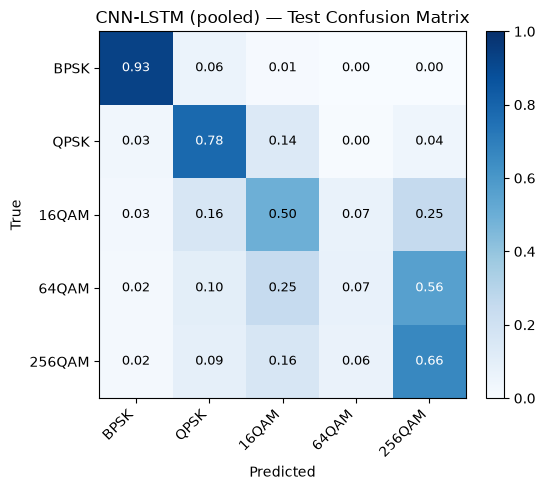

In [10]:
plot_confusion_matrix(mod_true_lstm, mod_pred_lstm, title="CNN-LSTM (pooled) — Test Confusion Matrix")

## 7. Full test set and high-SNR only

In [11]:
print("=== BaselineCNN, SNR >= 15 ===")
high_snr_confusion(mod_true_base, mod_pred_base, snr_base)

print("\n=== CNN-LSTM, SNR >= 15 ===")
high_snr_confusion(mod_true_lstm, mod_pred_lstm, snr_lstm)

=== BaselineCNN, SNR >= 15 ===
n=3090 samples at SNR>=15.0
            BPSK    QPSK   16QAM   64QAM  256QAM
    BPSK   0.997   0.003   0.000   0.000   0.000
    QPSK   0.000   0.961   0.023   0.002   0.015
   16QAM   0.000   0.028   0.576   0.139   0.257
   64QAM   0.000   0.016   0.126   0.126   0.731
  256QAM   0.000   0.019   0.070   0.092   0.819

=== CNN-LSTM, SNR >= 15 ===
n=3090 samples at SNR>=15.0
            BPSK    QPSK   16QAM   64QAM  256QAM
    BPSK   0.997   0.003   0.000   0.000   0.000
    QPSK   0.000   0.958   0.029   0.000   0.013
   16QAM   0.000   0.008   0.594   0.117   0.282
   64QAM   0.000   0.005   0.149   0.078   0.769
  256QAM   0.000   0.002   0.050   0.068   0.880


array([[0.99676375, 0.00323625, 0.        , 0.        , 0.        ],
       [0.        , 0.9579288 , 0.02912621, 0.        , 0.01294498],
       [0.        , 0.00809061, 0.59385113, 0.11650485, 0.2815534 ],
       [0.        , 0.00485437, 0.14886731, 0.0776699 , 0.76860841],
       [0.        , 0.00161812, 0.05016181, 0.06796117, 0.8802589 ]])

## 8. Accuracy vs SNR - BaselineCNN vs CNN-LSTM

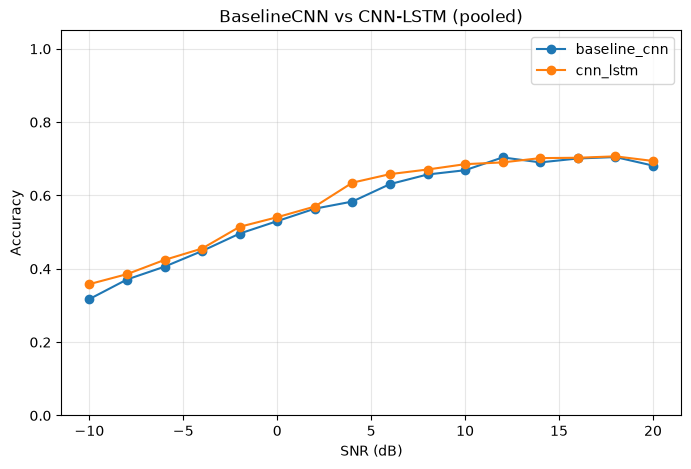

In [12]:
plot_accuracy_vs_snr_comparison(
    results,
    title="BaselineCNN vs CNN-LSTM (pooled)"
);

In [13]:
table_base = accuracy_vs_snr_table(mod_true_base, mod_pred_base, snr_base)
table_lstm = accuracy_vs_snr_table(mod_true_lstm, mod_pred_lstm, snr_lstm)

snr_levels = sorted(table_base["overall"].keys())
print(f"{'SNR':>6} | {'baseline_cnn':>12} | {'cnn_lstm':>10}")
for s in snr_levels:
    print(f"{s:6.1f} | {table_base['overall'][s]:12.3f} | {table_lstm['overall'][s]:10.3f}")

   SNR | baseline_cnn |   cnn_lstm
 -10.0 |        0.317 |      0.358
  -8.0 |        0.371 |      0.385
  -6.0 |        0.406 |      0.424
  -4.0 |        0.449 |      0.455
  -2.0 |        0.496 |      0.515
   0.0 |        0.530 |      0.541
   2.0 |        0.564 |      0.570
   4.0 |        0.583 |      0.635
   6.0 |        0.631 |      0.658
   8.0 |        0.657 |      0.671
  10.0 |        0.669 |      0.685
  12.0 |        0.704 |      0.690
  14.0 |        0.690 |      0.702
  16.0 |        0.701 |      0.703
  18.0 |        0.705 |      0.707
  20.0 |        0.682 |      0.694
